In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
import yfinance as yf

@tool
def get_stock_price(symbol: str) -> float:
    """Fetch the latest stock price for a given ticker symbol.

    Args:
        symbol: Stock ticker symbol, e.g. "MSFT", "AAPL", "TSLA".

    Returns:
        The latest traded price as a float.
    """
    ticker = yf.Ticker(symbol)
    price = ticker.fast_info.get("lastPrice")
    if price is None:
        raise ValueError(f"Could not find a price for symbol '{symbol}'")
    return int(price)

tools = [get_stock_price]
llm = init_chat_model("gemini-3.6-flash", model_provider="google_genai")
llm_with_tools = llm.bind_tools(tools)

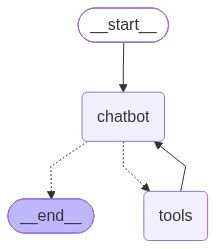

In [5]:
def chatbot(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [7]:
state = graph.invoke({"messages" : [{"role": "user", "content":  "I want to buy 10 msft stock and 10 google stock, what will be the total cost?"}]})
print(state["messages"][-1].content)

KeyboardInterrupt: 

In [ ]:
state = graph.invoke({"messages" : [{"role": "user", "content":  "who was Mahatma Gandhi?"}]})
print(state["messages"][-1].content)